# 🔴⚫ THOMASSON ENGINE v10 — RC Lens Data Scouting
**Auteur : Zakaria**

---

## Problématique
Identifier le successeur d'**Adrien Thomasson (32 ans)** dans les Big 5 Européens.  
Profil cible : **Pressing Playmaker hybride** — MF capable de presser haut ET de créer.

---

## Contraintes de recrutement
| Critère | Valeur |
|---|---|
| **Budget** | ≤ 15 M€ (Transfermarkt mars 2026) |
| **Âge** | ≤ 29 ans |
| **Minutes** | ≥ 50% du temps de jeu de Thomasson (~961 min) |
| **Poste** | MF confirmé (FBRef + SofaScore — ni défenseur ni ailier pur) |
| **Club exclu** | RC Lens (effectif actuel) |

---

## Stratégie v10 — 3 dimensions
| Dimension | Métriques clés | Poids |
|---|---|---|
| **Pressing** | TklW/90 · Int/90 · Duels Sol% · Clr/90 | 40% |
| **Création** | KP/90 · xA/90 · BC/90 · Ast/90 | 40% |
| **Transition** | Drib/90 · Pass3T/90 · Pass% | 20% |

## 0. Imports & Palette RC Lens

In [17]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

os.makedirs('src/figures', exist_ok=True)
FIGDIR = 'src/figures'

# ── Palette RC Lens ──────────────────────────────────────────────────────────
R  = '#E30613'   # rouge Lens
OR = '#F5A623'   # or
F  = '#0D0D0D'   # fond noir
F2 = '#141414'   # fond carte
W  = '#F0F0F0'   # blanc
G  = '#777777'   # gris
G2 = '#2A2A2A'   # gris foncé
VT = '#4CAF50'   # vert
OG = '#FF9800'   # orange
PU = '#9C27B0'   # violet
B  = '#00A8E8'   # bleu
AQ = '#00BCD4'   # cyan

plt.rcParams.update({
    'figure.facecolor':F, 'axes.facecolor':F2,
    'text.color':W,       'axes.labelcolor':W,
    'xtick.color':G,      'ytick.color':G,
    'axes.edgecolor':G2,  'axes.grid':True,
    'grid.color':G2,      'grid.linewidth':0.5,
    'font.family':'DejaVu Sans',
})
print("✅ Environnement prêt — Thomasson Engine v10")

✅ Environnement prêt — Thomasson Engine v10


## 1. Chargement des sources

In [18]:
big5  = pd.read_csv('big5_stats.csv',         sep=';', on_bad_lines='skip')
misc  = pd.read_csv('Miscellaneous_Stats.csv', on_bad_lines='skip')
defdf = pd.read_csv('stats_joueurs_final.csv', on_bad_lines='skip')
shoot = pd.read_csv('Shooting_Stats.csv',      on_bad_lines='skip')
gendf = pd.read_csv('general_Stats.csv',       on_bad_lines='skip')

for df in [misc, gendf, shoot]:
    df['_player'] = df['1_level_0_Player'].astype(str).str.strip()
defdf['_player']   = defdf['Player'].astype(str).str.strip()
defdf['Pos_fbref'] = defdf['Pos'].astype(str).str.strip()

print(f"big5  {big5.shape}  — SofaScore")
print(f"misc  {misc.shape}  — FBRef Misc (TklW, Int)")
print(f"defdf {defdf.shape}  — FBRef Defensive (positions)")
print(f"shoot {shoot.shape}  — FBRef Shooting (SoT/90)")

big5  (5248, 97)  — SofaScore
misc  (2653, 23)  — FBRef Misc (TklW, Int)
defdf (2653, 27)  — FBRef Defensive (positions)
shoot (2670, 21)  — FBRef Shooting (SoT/90)


## 2. Nettoyage & Fusion

**Règles :**
- Conversion numérique toutes colonnes métriques
- Suppression lignes de traduction SofaScore
- Déduplication sur `max(minutes)` (joueurs multi-clubs)
- Exclusion complète RC Lens
- Filtre position : MF SofaScore + FBRef non-DF/GK/FW pur
- Exclusion faux positifs (Dimarco LB, Yamal ailier…)
- Imputation médiane par position pour NaN post-fusion

In [19]:
# ── Nettoyage SofaScore ───────────────────────────────────────────────────────
COLS_NUM = [
    'minutesPlayed','rating','goals','assists','expectedGoals','expectedAssists',
    'keyPasses','tackles','interceptions','accuratePassesPercentage',
    'successfulDribbles','bigChancesCreated','fouls','wasFouled',
    'groundDuelsWonPercentage','aerialDuelsWonPercentage','player_age',
    'accurateFinalThirdPasses','clearances','accurateCrosses','appearances',
]
for c in COLS_NUM:
    big5[c] = pd.to_numeric(big5[c], errors='coerce')
big5 = big5.dropna(subset=['player__name','minutesPlayed','rating'])
big5 = big5[~big5['player__name'].str.contains('Translation|nameTranslation', na=False)]
big5 = (big5.sort_values('minutesPlayed', ascending=False)
             .drop_duplicates('player__name', keep='first')
             .reset_index(drop=True))
big5['_player'] = big5['player__name'].str.strip()

LENS_MASK    = big5['team__name'].str.contains('Lens', na=False, case=False)
joueurs_lens = big5[LENS_MASK]['player__name'].tolist()

# ── FBRef sources ─────────────────────────────────────────────────────────────
for c in ['Performance_TklW','Performance_Int','Performance_Crs','Performance_Fls','Performance_Fld']:
    misc[c] = pd.to_numeric(misc[c], errors='coerce')
misc_s = misc[['_player','Performance_TklW','Performance_Int','Performance_Crs']].rename(
    columns={'Performance_TklW':'TklW_misc','Performance_Int':'Int_misc','Performance_Crs':'Crs_misc'})

defdf['TklW'] = pd.to_numeric(defdf['TklW'], errors='coerce')
defdf['Int']  = pd.to_numeric(defdf['Int'],  errors='coerce')
def_s = defdf[['_player','TklW','Int','Pos_fbref']].rename(
    columns={'TklW':'TklW_def','Int':'Int_def'})

for c in ['Standard_Sh/90','Standard_SoT/90','Standard_SoT%','Standard_G/Sh']:
    shoot[c] = pd.to_numeric(shoot[c], errors='coerce')
shoot['_pos_s'] = shoot['3_level_0_Pos'].astype(str).str.strip()
shoot_s = shoot[['_player','Standard_Sh/90','Standard_SoT/90']].rename(
    columns={'Standard_Sh/90':'Sh90','Standard_SoT/90':'SoT90'})

# ── Fusion ────────────────────────────────────────────────────────────────────
df = big5[big5['minutesPlayed'] >= 600].copy()
df = (df.merge(misc_s, on='_player', how='left')
        .merge(def_s,  on='_player', how='left')
        .merge(shoot_s,on='_player', how='left'))

df['_pos_sofa'] = df['player_position'].astype(str).str.strip()
for col in ['TklW_misc','Int_misc','Crs_misc','TklW_def','Int_def','SoT90','Sh90']:
    if df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df.groupby('_pos_sofa')[col].transform('median')).fillna(df[col].median())

# ── Filtres positions & faux-positifs ─────────────────────────────────────────
EXCL_POS      = ['DF,MF','DF','GK','FW','DF,FW']
FAUX_POSITIFS = ['Federico Dimarco','Lamine Yamal','Abdessamad Ezzalzouli',
                 'Ferran Torres','Dani Olmo']

is_mf_sofa  = df['player_position'].str.contains('MF', na=False)
is_not_excl = ~df['Pos_fbref'].isin(EXCL_POS)
is_not_faux = ~df['player__name'].isin(FAUX_POSITIFS)
idx_lens    = LENS_MASK.reindex(df.index, fill_value=False)

T_raw = df[df['player__name'].str.contains('Thomasson', na=False)].copy()
pool  = df[is_mf_sofa & is_not_excl & is_not_faux & ~idx_lens].copy()
pool  = pool.drop_duplicates('player__name', keep='first').reset_index(drop=True)

print(f"Pool filtré     : {len(pool)} milieux uniques")
print(f"RC Lens exclus  : {len(joueurs_lens)} joueurs")
print(f"Thomasson isolé : {len(T_raw)} ligne(s)")

Pool filtré     : 643 milieux uniques
RC Lens exclus  : 24 joueurs
Thomasson isolé : 1 ligne(s)


## 3. Feature Engineering — Métriques /90

**3 dimensions de scoring :**
- **Pressing (40%)** : TklW FBRef (qualité > volume), Interceptions, Duels sol%, Clearances
- **Création (40%)** : Passes clés, xA, Big Chances créées, Assists
- **Transition (20%)** : Dribbles réussis, Passes 3e tiers, Précision passe — *dimension clé du profil Thomasson*

In [20]:
def add_p90(d):
    d = d.copy()
    d['p90'] = d['minutesPlayed'] / 90.0
    for c in ['goals','assists','expectedGoals','expectedAssists','keyPasses',
              'tackles','interceptions','bigChancesCreated','successfulDribbles',
              'fouls','wasFouled','clearances','accurateCrosses','accurateFinalThirdPasses']:
        if c in d.columns:
            d[f'{c}_p90'] = d[c] / d['p90']
    if 'TklW_def' in d.columns: d['TklW_p90']    = d['TklW_def'] / d['p90']
    if 'Int_def'  in d.columns: d['Int_def_p90'] = d['Int_def']  / d['p90']
    if 'SoT90'    in d.columns: d['SoT_p90']     = d['SoT90']
    return d

def compute_scores(d):
    d = d.copy()
    def gc(col):
        return d[col].fillna(0) if col in d.columns else pd.Series(0, index=d.index)

    # PRESSING (40%) — qualité défensive box-to-box
    d['s_press'] = (
        gc('TklW_p90')                       * 0.40 +
        gc('interceptions_p90')              * 0.30 +
        gc('groundDuelsWonPercentage') / 100 * 0.20 +
        gc('clearances_p90')                 * 0.10
    )
    # CRÉATION (40%) — impact offensif
    d['s_crea'] = (
        gc('keyPasses_p90')         * 0.30 +
        gc('expectedAssists_p90')   * 0.25 +
        gc('bigChancesCreated_p90') * 0.25 +
        gc('assists_p90')           * 0.20
    )
    # TRANSITION (20%) — cassage de lignes, portée de balle
    d['s_trans'] = (
        gc('successfulDribbles_p90')        * 0.35 +
        gc('accurateFinalThirdPasses_p90')  * 0.35 +
        gc('accuratePassesPercentage') / 100 * 0.30
    )
    d['s_final'] = d['s_press']*0.40 + d['s_crea']*0.40 + d['s_trans']*0.20
    return d

pool  = compute_scores(add_p90(pool))
T_df  = compute_scores(add_p90(T_raw))

# Normalisation 0–100 sur pool + Thomasson combinés
all_mf = pd.concat([pool, T_df], ignore_index=True).drop_duplicates('player__name', keep='first')
for s in ['s_final','s_press','s_crea','s_trans']:
    all_mf[f'{s}_n'] = MinMaxScaler((0,100)).fit_transform(all_mf[[s]])

T  = all_mf[all_mf['player__name'].str.contains('Thomasson', na=False)].iloc[0]
MF = all_mf[~all_mf['player__name'].str.contains('Thomasson', na=False)].copy()
MF['player_age'] = pd.to_numeric(MF['player_age'], errors='coerce')

print(f"THOMASSON — Scores v10 normalisés (0–100) :")
print(f"  Final     : {T['s_final_n']:.1f}")
print(f"  Pressing  : {T['s_press_n']:.1f}")
print(f"  Création  : {T['s_crea_n']:.1f}")
print(f"  Transition: {T['s_trans_n']:.1f}")

THOMASSON — Scores v10 normalisés (0–100) :
  Final     : 37.6
  Pressing  : 45.2
  Création  : 65.0
  Transition: 23.6


## 4. Profil Thomasson — Radiographie percentile

In [21]:
PCT_MAP = {
    'TklW/90 (FBRef)'            : 'TklW_p90',
    'Interceptions/90'           : 'interceptions_p90',
    'Duels sol gagnés (%)'       : 'groundDuelsWonPercentage',
    'Passes Clés/90'             : 'keyPasses_p90',
    'xA/90'                      : 'expectedAssists_p90',
    'Big Chances créées/90'      : 'bigChancesCreated_p90',
    'Dribbles réussis/90'        : 'successfulDribbles_p90',
    'Passes Finales 3e tiers/90' : 'accurateFinalThirdPasses_p90',
    'Précision passes (%)'       : 'accuratePassesPercentage',
    'Rating SofaScore'           : 'rating',
}

print("=" * 72)
print(f"ADRIEN THOMASSON  ·  RC Lens  ·  MF  ·  {T['player_age']:.0f} ans")
print(f"{T['minutesPlayed']:.0f} min jouées  ·  {T['appearances']:.0f} matchs  ·  Rating {T['rating']:.2f}")
print("=" * 72)
print(f"{'Métrique':<40}  {'Valeur':>8}  {'Pctile':>7}  Profil")
print("-" * 72)

for label, col in PCT_MAP.items():
    val = float(T[col]) if col in T.index and not pd.isna(T[col]) else 0.0
    ref = MF[col].dropna() if col in MF.columns else pd.Series([0])
    pct = (ref < val).mean() * 100
    bar = '▓' * int(pct/5) + '░' * (20 - int(pct/5))
    tag = '⭐ ÉLITE' if pct>=80 else ('✅ BON' if pct>=55 else ('⚠️  MOY.' if pct>=35 else '❌ FAIB.'))
    print(f"  {label:<40} {val:>8.2f}  →{pct:>5.0f}%  {bar}  {tag}")

ADRIEN THOMASSON  ·  RC Lens  ·  MF  ·  32 ans
1922 min jouées  ·  22 matchs  ·  Rating 6.88
Métrique                                    Valeur   Pctile  Profil
------------------------------------------------------------------------
  TklW/90 (FBRef)                              1.55  →   89%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░  ⭐ ÉLITE
  Interceptions/90                             0.66  →   48%  ▓▓▓▓▓▓▓▓▓░░░░░░░░░░░  ⚠️  MOY.
  Duels sol gagnés (%)                        44.21  →   30%  ▓▓▓▓▓░░░░░░░░░░░░░░░  ❌ FAIB.
  Passes Clés/90                               2.43  →   97%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░  ⭐ ÉLITE
  xA/90                                        0.19  →   84%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░  ⭐ ÉLITE
  Big Chances créées/90                        0.33  →   79%  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓░░░░░  ✅ BON
  Dribbles réussis/90                          0.52  →   36%  ▓▓▓▓▓▓▓░░░░░░░░░░░░░  ⚠️  MOY.
  Passes Finales 3e tiers/90                  10.30  →   65%  ▓▓▓▓▓▓▓▓▓▓▓▓░░░░░░░░  ✅ BON
  Précision passes (%)          

## 5. Filtres de recrutement — Entonnoir

```
Pool total  →  ≥961 min  →  ≤29 ans  →  ≤15 M€ (budget confirmé)  →  Shortlist
```

> **Valeurs de marché Transfermarkt mars 2026 — confirmées :**  
> James Garner = 35 M€ ❌ · Anton Stach = 25 M€ ❌ · Aron Dønnum = 5 M€ ✅

In [22]:
# ── Valeurs de marché (Transfermarkt mars 2026) ───────────────────────────────
VALEURS = {
    # Confirmées dans l'analyse
    'Aron Dønnum'           :  5.0,   # ✅
    'Edu Expósito'          : 10.0,   # ✅
    'Patrizio Masini'       :  3.0,   # ✅
    'Romain Del Castillo'   :  5.0,   # ✅
    'Vitaly Janelt'         : 10.0,   # ✅
    'Afonso Moreira'        :  4.0,   # ✅
    'Aarón Martín'          :  8.0,   # ✅
    'Kassoum Ouattara'      :  6.0,   # ✅
    'Mehdi Léris'           :  3.0,   # ✅
    'Elliot Anderson'       : 15.0,   # ✅ limite
    'Florentino Luís'       : 12.0,   # ✅
    'Hugo Bueno'            :  8.0,   # ✅
    'Tim Iroegbunam'        : 12.0,   # ✅
    'Johann Lepenant'       :  5.0,   # ✅
    'Nathaniel Brown'       :  5.0,   # ✅
    'Ander Barrenetxea'     : 10.0,   # ✅
    'Cristian Cásseres Jr.' :  8.0,   # ✅
    'Martin Frese'          :  4.0,   # ✅
    'Jan-Niklas Beste'      : 10.0,   # ✅
    'Saša Lukić'            :  8.0,   # ✅
    'Youri Tielemans'       : 10.0,   # ✅
    'Kévin Danois'          : 10.0,   # ✅
    # Hors budget — exclus
    'James Garner'          : 35.0,   # ❌
    'Anton Stach'           : 25.0,   # ❌
    'Mikkel Damsgaard'      : 20.0,   # ❌
    'Lamine Camara'         : 40.0,   # ❌
    'Patrick Dorgu'         : 40.0,   # ❌
    'Arda Güler'            : 35.0,   # ❌
    'Rayan Cherki'          : 50.0,   # ❌
    'Jude Bellingham'       : 200.0,  # ❌
    'Pedri'                 : 80.0,   # ❌
}

MF['valeur_m'] = MF['player__name'].map(VALEURS)

# ── Entonnoir ─────────────────────────────────────────────────────────────────
MIN_THRESH = T['minutesPlayed'] * 0.50   # ~961 min
BUDGET_MAX = 15.0
AGE_MAX    = 29

n0 = len(MF)
MF_min = MF[MF['minutesPlayed'] >= MIN_THRESH].copy()
n1 = len(MF_min)
MF_age = MF_min[MF_min['player_age'] <= AGE_MAX].copy()
n2 = len(MF_age)
MF_bud = MF_age[MF_age['valeur_m'].notna() & (MF_age['valeur_m'] <= BUDGET_MAX)].copy()
n3 = len(MF_bud)
ETAPES = [n0, n1, n2, n3]

print(f"{'Pool MF total':<32}: {n0:>4}")
print(f"{'≥ '+ str(int(MIN_THRESH)) +' min (50% Thomasson)':<32}: {n1:>4}  (-{n0-n1})")
print(f"{'≤ '+str(AGE_MAX)+' ans':<32}: {n2:>4}  (-{n1-n2})")
print(f"{'≤ '+str(BUDGET_MAX)+'M€ + valeur connue':<32}: {n3:>4}  (-{n2-n3})")
print()
print("TOP 10 candidats éligibles :")
print(f"{'#':>2}  {'Joueur':<26} {'Club':<22} {'Âge':>4} {'Min':>6} {'Score':>6} {'Budget':>7}")
print("-"*80)
for i,(_,r) in enumerate(MF_bud.nlargest(10,'s_final_n').iterrows(),1):
    print(f"{i:>2}  {r['player__name']:<26} {str(r['team__name']):<22} "
          f"{r['player_age']:>4.0f} {r['minutesPlayed']:>6.0f} "
          f"{r['s_final_n']:>6.1f} ~{r['valeur_m']:>4.0f}M€")

Pool MF total                   :  642
≥ 961 min (50% Thomasson)       :  471  (-171)
≤ 29 ans                        :  385  (-86)
≤ 15.0M€ + valeur connue        :   21  (-364)

TOP 10 candidats éligibles :
 #  Joueur                     Club                    Âge    Min  Score  Budget
--------------------------------------------------------------------------------
 1  Elliot Anderson            Nottingham Forest        23   2417   53.7 ~  15M€
 2  Youri Tielemans            Aston Villa              28   1299   48.3 ~  10M€
 3  Ander Barrenetxea          Real Sociedad            24   1099   42.6 ~  10M€
 4  Edu Expósito               Espanyol                 29   1602   41.3 ~  10M€
 5  Kévin Danois               Auxerre                  21   1848   39.7 ~  10M€
 6  Aron Dønnum                Toulouse                 27   1681   38.0 ~   5M€
 7  Vitaly Janelt              Brentford                27   1267   37.8 ~  10M€
 8  Romain Del Castillo        Stade Brestois           29   1

## 6. Shortlist finale — 5 candidats

In [23]:
# ── Shortlist v10 — validée budget · minutes · profil ────────────────────────
SHORTLIST_V10 = {
    'Elliot Anderson'     : ('Nottingham Forest', 'PL',      15.0, '23 ans', B),
    'Youri Tielemans'     : ('Aston Villa',       'PL',      10.0, '28 ans', VT),
    'Edu Expósito'        : ('Espanyol',          'La Liga', 10.0, '29 ans', OR),
    'Aron Dønnum'         : ('Toulouse',          'Ligue 1',  5.0, '27 ans', PU),
    'Romain Del Castillo' : ('Stade Brestois',    'Ligue 1',  5.0, '29 ans', OG),
}

print("SHORTLIST FINALE v10")
print("=" * 92)
print(f"{'Réf.':<22} {'Club':<20} {'Âge':>5} {'Budget':>8}  {'Final':>6} {'Press':>6} {'Crea':>6} {'Trans':>6}  {'TklW':>6} {'KP':>5} {'xA':>6} {'Min':>6}")
print("-" * 92)

# Thomasson référence
print(f"{'Thomasson (REF)':<22} {'RC Lens':<20} {T['player_age']:>5.0f} {'—':>8}  "
      f"{T['s_final_n']:>6.1f} {T['s_press_n']:>6.1f} {T['s_crea_n']:>6.1f} {T['s_trans_n']:>6.1f}  "
      f"{T.get('TklW_p90',0):>6.2f} {T.get('keyPasses_p90',0):>5.2f} "
      f"{T.get('expectedAssists_p90',0):>6.3f} {T['minutesPlayed']:>6.0f}")
print("-" * 92)

for name,(club,ligue,bud,age,col) in SHORTLIST_V10.items():
    kw = name.split()[-1]
    r  = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        print(f"{r['player__name']:<22} {club:<20} {r['player_age']:>5.0f} ~{bud:>5.0f}M€  "
              f"{r['s_final_n']:>6.1f} {r['s_press_n']:>6.1f} {r['s_crea_n']:>6.1f} {r['s_trans_n']:>6.1f}  "
              f"{r.get('TklW_p90',0):>6.2f} {r.get('keyPasses_p90',0):>5.2f} "
              f"{r.get('expectedAssists_p90',0):>6.3f} {r['minutesPlayed']:>6.0f}")

SHORTLIST FINALE v10
Réf.                   Club                   Âge   Budget   Final  Press   Crea  Trans    TklW    KP     xA    Min
--------------------------------------------------------------------------------------------
Thomasson (REF)        RC Lens                 32        —    37.6   45.2   65.0   23.6    1.55  2.43  0.190   1922
--------------------------------------------------------------------------------------------
Elliot Anderson        Nottingham Forest       23 ~   15M€    53.7   56.8   34.6   47.8    1.68  1.49  0.114   2417
Youri Tielemans        Aston Villa             28 ~   10M€    48.3   50.2   49.6   39.4    1.73  1.80  0.181   1299
Edu Expósito           Espanyol                29 ~   10M€    41.3   36.7   86.4   26.0    1.01  3.20  0.298   1602
Aron Dønnum            Toulouse                27 ~    5M€    38.0   42.7   61.4   25.8    1.23  2.30  0.261   1681
Romain Del Castillo    Stade Brestois          29 ~    5M€    37.5   45.1   63.6   23.8    1.46  

## 7. Visualisations

### Fig 1 — Radar Thomasson (9 axes · 3 dimensions)

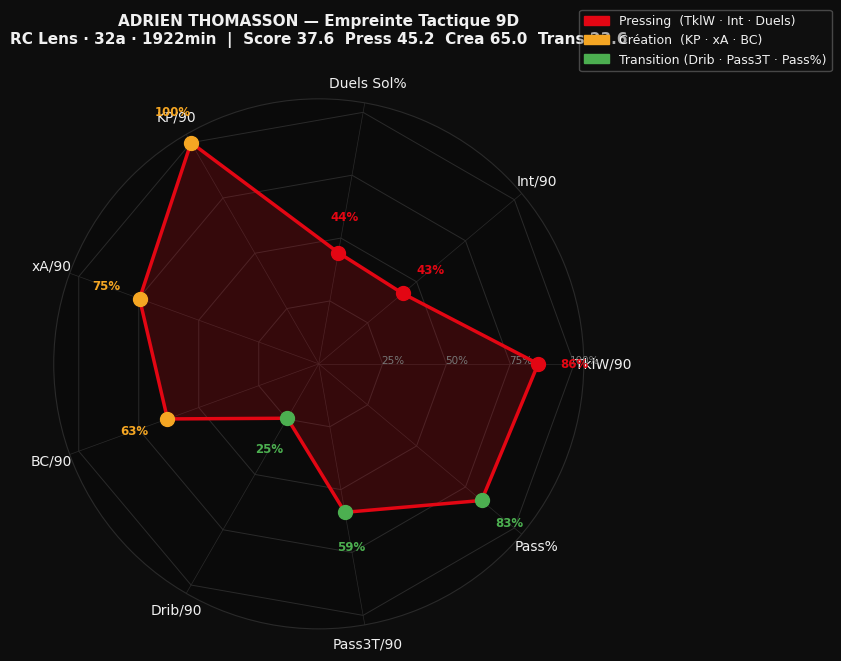

In [24]:
RADAR_LABELS = [
    'TklW/90','Int/90','Duels Sol%',
    'KP/90','xA/90','BC/90',
    'Drib/90','Pass3T/90','Pass%',
]
RADAR_COLS = [
    'TklW_p90','interceptions_p90','groundDuelsWonPercentage',
    'keyPasses_p90','expectedAssists_p90','bigChancesCreated_p90',
    'successfulDribbles_p90','accurateFinalThirdPasses_p90','accuratePassesPercentage',
]
N  = len(RADAR_LABELS)
MV = [MF[c].quantile(0.95) if c in MF.columns else 1.0 for c in RADAR_COLS]
MV[2] = 100.0; MV[-1] = 100.0   # % → déjà sur 100
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
DIM_COLORS = [R]*3 + [OR]*3 + [VT]*3   # Pressing / Création / Transition

def radar_vals(row):
    raw = [float(row[c]) if c in row.index and not pd.isna(row[c]) else 0.0 for c in RADAR_COLS]
    return [min(v/m, 1.0) if m > 0 else 0.0 for v,m in zip(raw, MV)]

tv = radar_vals(T) + [radar_vals(T)[0]]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True), facecolor=F)
fig.patch.set_facecolor(F); ax.set_facecolor('#0A0A0A')

for ring in [0.25, 0.5, 0.75, 1.0]:
    ax.plot(angles,[ring]*len(angles),'-',color=G2,lw=0.7)
    ax.text(0, ring+0.04, f'{ring*100:.0f}%', ha='center', fontsize=7.5, color=G)

ax.fill(angles, tv, color=R, alpha=0.20, zorder=2)
ax.plot(angles, tv, 'o-', color=R, lw=2.5, ms=8, zorder=3)

for i,(ang,val) in enumerate(zip(angles[:-1], tv[:-1])):
    c = DIM_COLORS[i]
    ax.plot(ang, val, 'o', color=c, ms=10, zorder=4)
    ax.text(ang, val+0.14, f'{val*100:.0f}%',
            ha='center', va='center', fontsize=8.5, color=c, fontweight='bold')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_LABELS, size=10, color=W)
ax.set_yticks([]); ax.spines['polar'].set_color(G2)

handles = [
    mpatches.Patch(color=R,  label='Pressing  (TklW · Int · Duels)'),
    mpatches.Patch(color=OR, label='Création  (KP · xA · BC)'),
    mpatches.Patch(color=VT, label='Transition (Drib · Pass3T · Pass%)'),
]
ax.legend(handles=handles, loc='upper right', bbox_to_anchor=(1.48,1.18),
          fontsize=9, framealpha=0.3, labelcolor=W)
ax.set_title(
    f"ADRIEN THOMASSON — Empreinte Tactique 9D\n"
    f"RC Lens · {T['player_age']:.0f}a · {T['minutesPlayed']:.0f}min  |  "
    f"Score {T['s_final_n']:.1f}  Press {T['s_press_n']:.1f}  Crea {T['s_crea_n']:.1f}  Trans {T['s_trans_n']:.1f}",
    color=W, fontsize=11, fontweight='bold', pad=40)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig1_radar_thomasson.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

### Fig 2 — Entonnoir de sélection

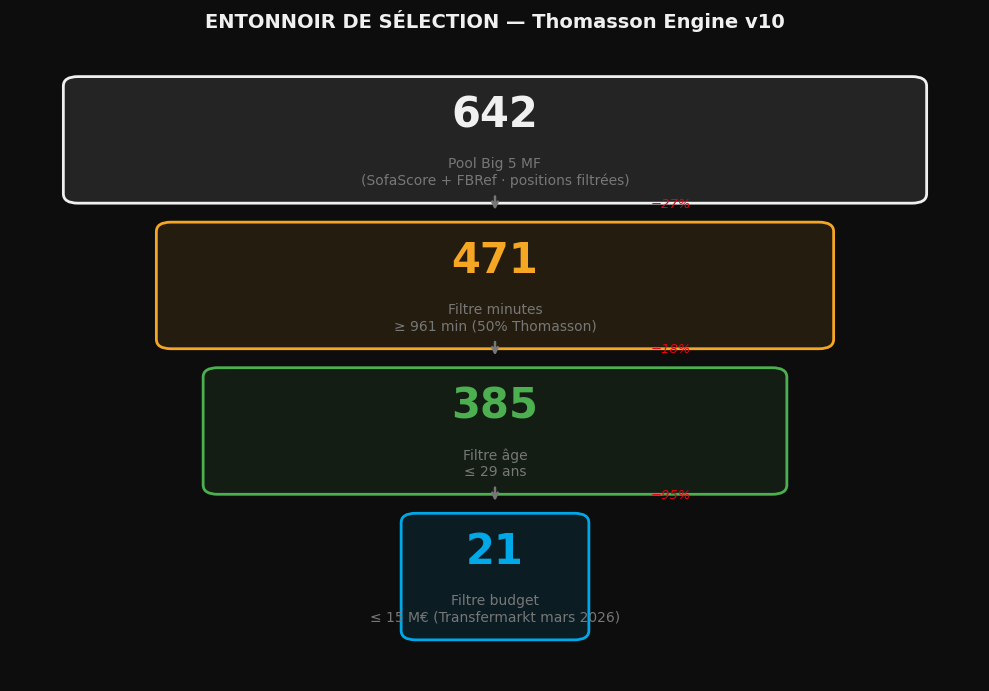

In [25]:
fig, ax = plt.subplots(figsize=(10,7), facecolor=F)
ax.set_facecolor(F); ax.axis('off')

STEPS = [
    ('Pool Big 5 MF\n(SofaScore + FBRef · positions filtrées)', ETAPES[0], W,  0.87),
    (f'Filtre minutes\n≥ {MIN_THRESH:.0f} min (50% Thomasson)',           ETAPES[1], OR, 0.64),
    (f'Filtre âge\n≤ {AGE_MAX} ans',                                      ETAPES[2], VT, 0.41),
    (f'Filtre budget\n≤ {BUDGET_MAX:.0f} M€ (Transfermarkt mars 2026)',   ETAPES[3], B,  0.18),
]

for i,(label,n,col,y) in enumerate(STEPS):
    w  = 0.14 + (n / ETAPES[0]) * 0.72
    x0 = 0.5 - w/2
    rect = mpatches.FancyBboxPatch(
        (x0, y-0.10), w, 0.17,
        boxstyle='round,pad=0.015',
        facecolor=mcolors.to_rgba(col,0.10),
        edgecolor=col, linewidth=2,
        transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(0.5, y+0.025, f'{n}', ha='center', va='center',
            transform=ax.transAxes, fontsize=30, color=col, fontweight='bold')
    ax.text(0.5, y-0.065, label, ha='center', va='center',
            transform=ax.transAxes, fontsize=10, color=G)
    if i < len(STEPS)-1:
        _,n2,_,y2 = STEPS[i+1]
        pct = (1 - n2/n)*100
        ax.annotate('', xy=(0.5,y2+0.10), xytext=(0.5,y-0.10),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color=G, lw=1.8))
        ax.text(0.66,(y+y2)/2, f'−{pct:.0f}%', ha='left', va='center',
                transform=ax.transAxes, fontsize=9.5, color=R, style='italic')

ax.set_title('ENTONNOIR DE SÉLECTION — Thomasson Engine v10',
             color=W, fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig2_entonnoir.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

### Fig 3 — Scatter Pressing × Création (3D couleur = Transition)

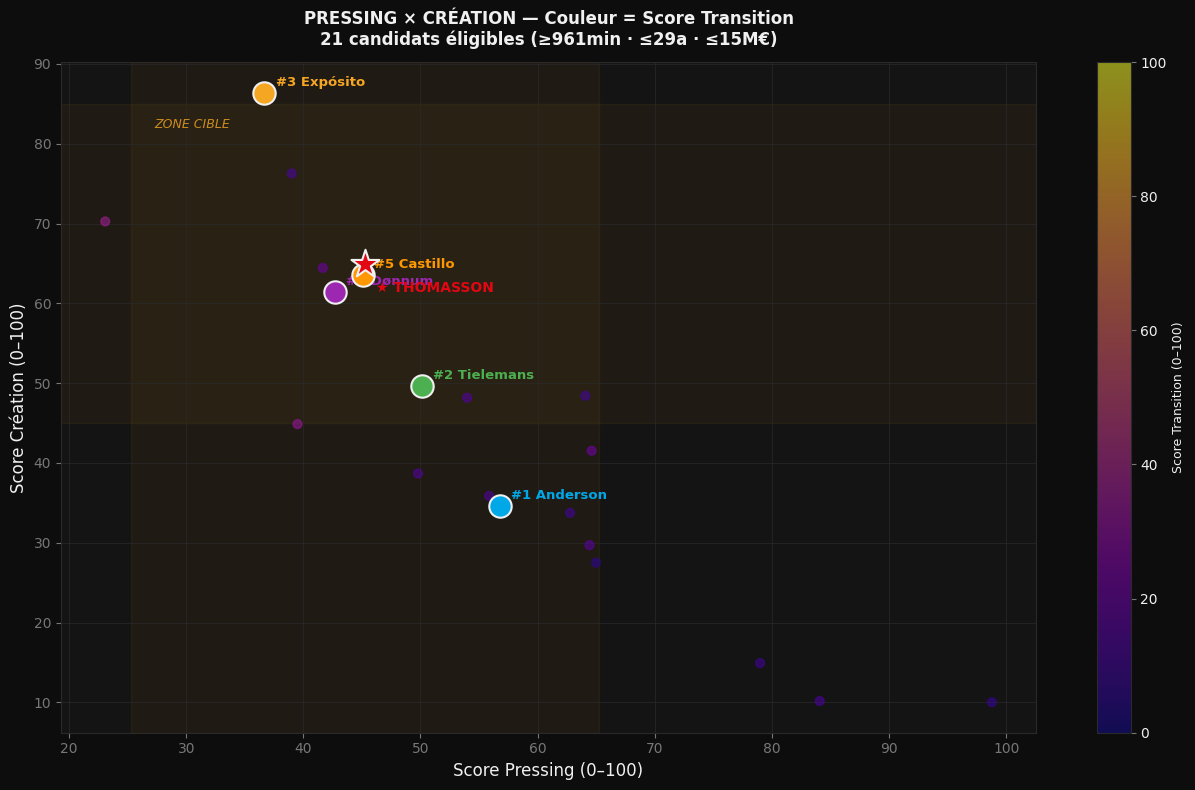

In [26]:
fig, ax = plt.subplots(figsize=(13,8), facecolor=F)

mfp = MF_bud.copy()
sc = ax.scatter(mfp['s_press_n'], mfp['s_crea_n'],
                c=mfp['s_trans_n'], cmap='plasma',
                s=40, alpha=0.55, vmin=0, vmax=100, zorder=2)

# Zone profil Thomasson
ax.axvspan(T['s_press_n']-20, T['s_press_n']+20, alpha=0.05, color=OR)
ax.axhspan(T['s_crea_n'] -20, T['s_crea_n'] +20, alpha=0.05, color=OR)
ax.text(T['s_press_n']-18, T['s_crea_n']+17, 'ZONE CIBLE',
        color=OR, fontsize=9, alpha=0.8, style='italic')

# Shortlist annotée
CANDS = [
    ('Anderson',  B,  '#1'), ('Tielemans', VT, '#2'),
    ('Expósito',  OR, '#3'), ('Dønnum',    PU, '#4'),
    ('Castillo',  OG, '#5'),
]
for kw,col,rank in CANDS:
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        ax.scatter(r['s_press_n'], r['s_crea_n'],
                   c=[col], s=260, edgecolors=W, linewidths=1.5, zorder=6)
        ax.annotate(f"{rank} {r['player__name'].split()[-1]}",
                    xy=(r['s_press_n'],r['s_crea_n']),
                    xytext=(8,5), textcoords='offset points',
                    fontsize=9.5, color=col, fontweight='bold')

# Thomasson
ax.scatter(T['s_press_n'], T['s_crea_n'], c=R, s=450,
           marker='*', edgecolors=W, lw=1.5, zorder=7)
ax.annotate('★ THOMASSON',xy=(T['s_press_n'],T['s_crea_n']),
            xytext=(8,-20), textcoords='offset points',
            fontsize=10, color=R, fontweight='bold')

cb = plt.colorbar(sc, ax=ax)
cb.set_label('Score Transition (0–100)', color=W, fontsize=9)
plt.setp(cb.ax.yaxis.get_ticklabels(), color=W)
ax.set_xlabel('Score Pressing (0–100)', fontsize=12)
ax.set_ylabel('Score Création (0–100)', fontsize=12)
ax.set_title(
    'PRESSING × CRÉATION — Couleur = Score Transition\n'
    f'{len(mfp)} candidats éligibles (≥{MIN_THRESH:.0f}min · ≤{AGE_MAX}a · ≤{BUDGET_MAX:.0f}M€)',
    color=W, fontsize=12, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig3_scatter.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

### Fig 4 — Heatmap percentiles 10 KPIs

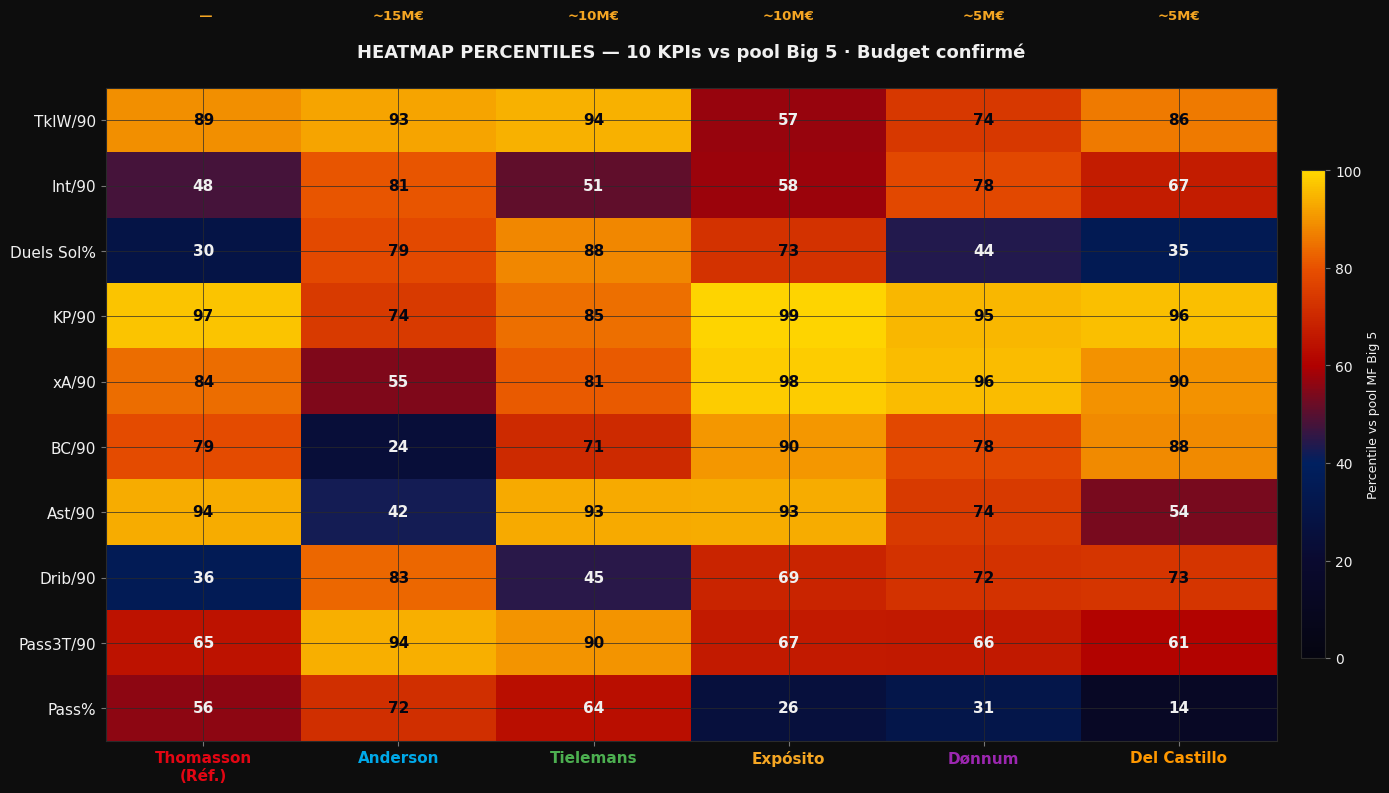

In [27]:
METRICS_HM = {
    'TklW/90'      : 'TklW_p90',
    'Int/90'       : 'interceptions_p90',
    'Duels Sol%'   : 'groundDuelsWonPercentage',
    'KP/90'        : 'keyPasses_p90',
    'xA/90'        : 'expectedAssists_p90',
    'BC/90'        : 'bigChancesCreated_p90',
    'Ast/90'       : 'assists_p90',
    'Drib/90'      : 'successfulDribbles_p90',
    'Pass3T/90'    : 'accurateFinalThirdPasses_p90',
    'Pass%'        : 'accuratePassesPercentage',
}

SL_KEYS  = ['Anderson','Tielemans','Expósito','Dønnum','Castillo']
SL_DISP  = ['Anderson','Tielemans','Expósito','Dønnum','Del Castillo']
SL_COLS  = [B, VT, OR, PU, OG]
SL_BUDG  = ['~15M€','~10M€','~10M€','~5M€','~5M€']

players = [T.to_frame().T.copy()]
lbls    = ['Thomasson\n(Réf.)']
budgets = ['  — ']
cols_lbl= [R]

for kw,disp,col,bud in zip(SL_KEYS,SL_DISP,SL_COLS,SL_BUDG):
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        players.append(r.iloc[0:1].copy())
        lbls.append(disp); budgets.append(bud); cols_lbl.append(col)

ap  = pd.concat(players, ignore_index=True)
mc  = list(METRICS_HM.values())
ml  = list(METRICS_HM.keys())
mat = np.zeros((len(mc), len(ap)))

for j in range(len(ap)):
    for i,col in enumerate(mc):
        val = float(ap.iloc[j][col]) if col in ap.columns and not pd.isna(ap.iloc[j][col]) else 0.0
        ref = MF[col].dropna() if col in MF.columns else pd.Series([0])
        mat[i,j] = (ref < val).mean() * 100

fig, ax = plt.subplots(figsize=(14,8), facecolor=F)
cmap_hm = mcolors.LinearSegmentedColormap.from_list(
    'lens', ['#050510','#0A0A30','#002060','#B00000','#E85000','#FFD700'])
im = ax.imshow(mat, cmap=cmap_hm, aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(lbls)))
ax.set_xticklabels(lbls, fontsize=11, fontweight='bold')
for tick,col in zip(ax.get_xticklabels(), cols_lbl):
    tick.set_color(col)
ax.set_yticks(range(len(ml)))
ax.set_yticklabels(ml, fontsize=11, color=W)

for i in range(len(ml)):
    for j in range(len(ap)):
        ctxt = '#050510' if mat[i,j] > 70 else W
        ax.text(j, i, f'{mat[i,j]:.0f}',
                ha='center', va='center', fontsize=11, color=ctxt, fontweight='bold')

for j,b in enumerate(budgets):
    ax.text(j, -1.5, b, ha='center', va='bottom', fontsize=9.5, color=OR, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label('Percentile vs pool MF Big 5', color=W, fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=W)

ax.set_title('HEATMAP PERCENTILES — 10 KPIs vs pool Big 5 · Budget confirmé',
             color=W, fontsize=13, fontweight='bold', pad=22)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig4_heatmap.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

### Fig 5 — Radars comparatifs Top 3 vs Thomasson

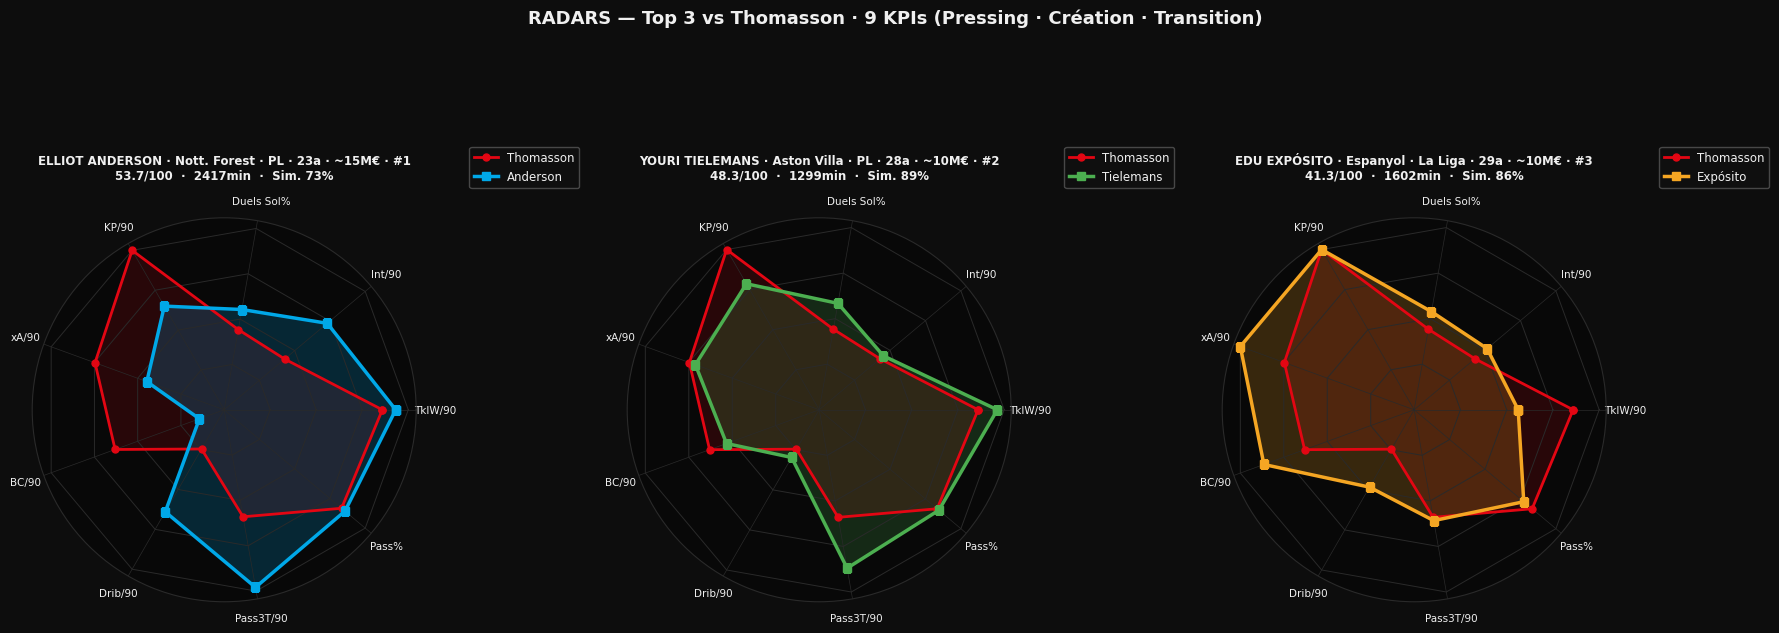

In [28]:
COMP3 = [
    ('Anderson',  B,  'ELLIOT ANDERSON · Nott. Forest · PL · 23a · ~15M€ · #1'),
    ('Tielemans', VT, 'YOURI TIELEMANS · Aston Villa · PL · 28a · ~10M€ · #2'),
    ('Expósito',  OR, 'EDU EXPÓSITO · Espanyol · La Liga · 29a · ~10M€ · #3'),
]

fig, axes = plt.subplots(1, 3, figsize=(18,7),
                          subplot_kw=dict(polar=True), facecolor=F)
fig.patch.set_facecolor(F)

for ax,(kw,col,title) in zip(axes, COMP3):
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): ax.axis('off'); continue
    r  = r.iloc[0]
    cv = radar_vals(r) + [radar_vals(r)[0]]

    ax.set_facecolor('#080808')
    for ring in [0.25,0.5,0.75,1.0]:
        ax.plot(angles,[ring]*len(angles),'-',color=G2,lw=0.7)
    ax.fill(angles, tv, color=R,   alpha=0.15)
    ax.plot(angles, tv, 'o-', color=R,   lw=2.0, ms=5, label='Thomasson')
    ax.fill(angles, cv, color=col, alpha=0.20)
    ax.plot(angles, cv, 's-', color=col, lw=2.5, ms=6, label=r['player__name'].split()[-1])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(RADAR_LABELS, size=7.5, color=W)
    ax.set_yticks([]); ax.spines['polar'].set_color(G2)

    sim = (1 - np.mean(np.abs(np.array(tv[:-1]) - np.array(cv[:-1])))) * 100
    ax.legend(loc='upper right', bbox_to_anchor=(1.44,1.2),
              fontsize=8.5, framealpha=0.3, labelcolor=W)
    ax.set_title(
        f"{title}\n{r['s_final_n']:.1f}/100  ·  {r['minutesPlayed']:.0f}min  ·  Sim. {sim:.0f}%",
        color=W, fontsize=8.5, fontweight='bold', pad=28)

fig.suptitle('RADARS — Top 3 vs Thomasson · 9 KPIs (Pressing · Création · Transition)',
             color=W, fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig5_radars.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

### Fig 6 — Budget RC Lens

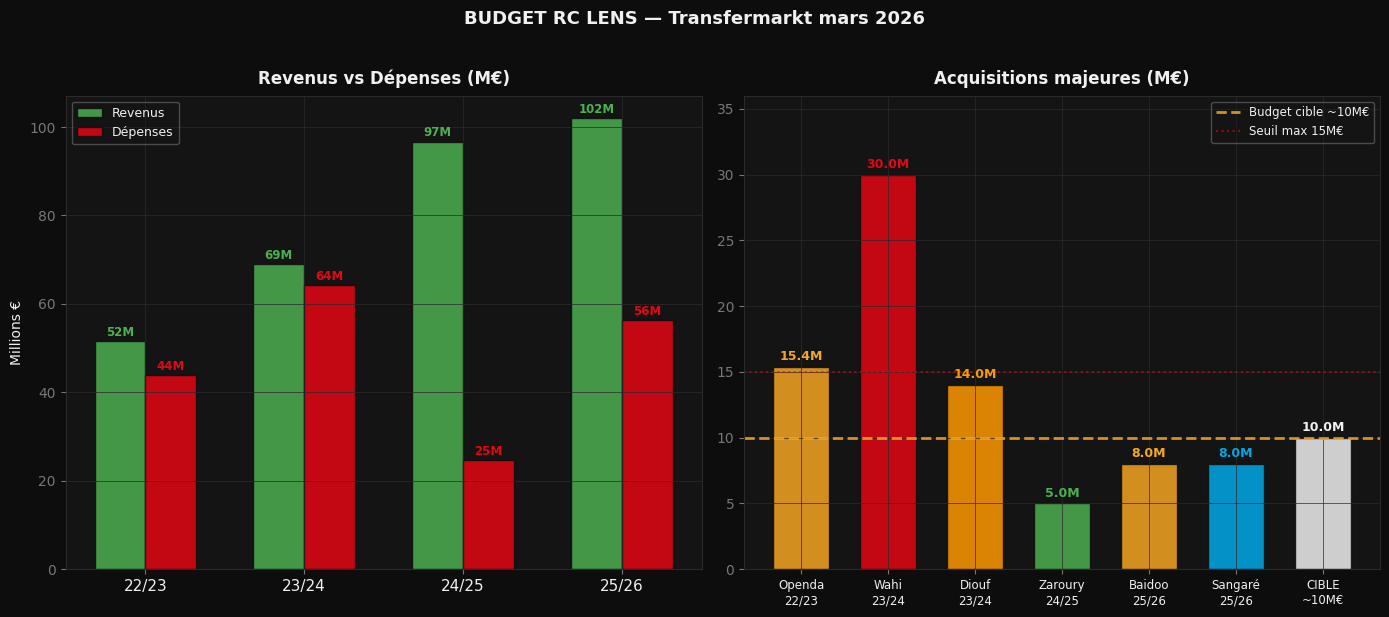

In [29]:
fig, axes = plt.subplots(1,2, figsize=(14,6), facecolor=F)

# Gauche — flux transferts par saison
ax = axes[0]
saisons = ['22/23','23/24','24/25','25/26']
rev = [51.6, 69.0, 96.7, 102.0]
dep = [43.9, 64.3, 24.7,  56.4]
sol = [r-d for r,d in zip(rev,dep)]
x, w = np.arange(4), 0.32
b1 = ax.bar(x-w/2, rev, w, label='Revenus',  color=VT, alpha=0.85, edgecolor=F)
b2 = ax.bar(x+w/2, dep, w, label='Dépenses', color=R,  alpha=0.85, edgecolor=F)
for bar,val,c in zip(list(b1)+list(b2), rev+dep, [VT]*4+[R]*4):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.2,
            f'{val:.0f}M', ha='center', fontsize=8.5, color=c, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(saisons, color=W, fontsize=11)
ax.set_ylabel('Millions €', color=W)
ax.set_title('Revenus vs Dépenses (M€)', color=W, fontweight='bold', pad=8)
ax.legend(fontsize=9, framealpha=0.3, labelcolor=W)

# Droite — positionnement budget cible dans l'historique
ax2 = axes[1]
ACQS = [
    ('Openda\n22/23',  15.4, OR),('Wahi\n23/24',    30.0, R),
    ('Diouf\n23/24',   14.0, OG),('Zaroury\n24/25',  5.0, VT),
    ('Baidoo\n25/26',   8.0, OR),('Sangaré\n25/26',  8.0, B),
    ('CIBLE\n~10M€',   10.0, W),
]
bars = ax2.bar(range(len(ACQS)), [v for _,v,_ in ACQS],
               color=[c for _,_,c in ACQS], alpha=0.85, edgecolor=F, width=0.65)
for bar,(_,val,col) in zip(bars, ACQS):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val}M', ha='center', fontsize=9, color=col, fontweight='bold')
ax2.axhline(10, color=OR, ls='--', lw=2.0, alpha=0.85, label='Budget cible ~10M€')
ax2.axhline(15, color=R,  ls=':',  lw=1.5, alpha=0.60, label='Seuil max 15M€')
ax2.set_xticks(range(len(ACQS)))
ax2.set_xticklabels([n for n,_,_ in ACQS], fontsize=8.5, color=W)
ax2.set_ylim(0,36); ax2.legend(fontsize=8.5, framealpha=0.3, labelcolor=W)
ax2.set_title('Acquisitions majeures (M€)', color=W, fontweight='bold', pad=8)

fig.suptitle('BUDGET RC LENS — Transfermarkt mars 2026',
             color=W, fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig6_budget.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

### Fig 7 — Podium final (5 candidats avec barres score)

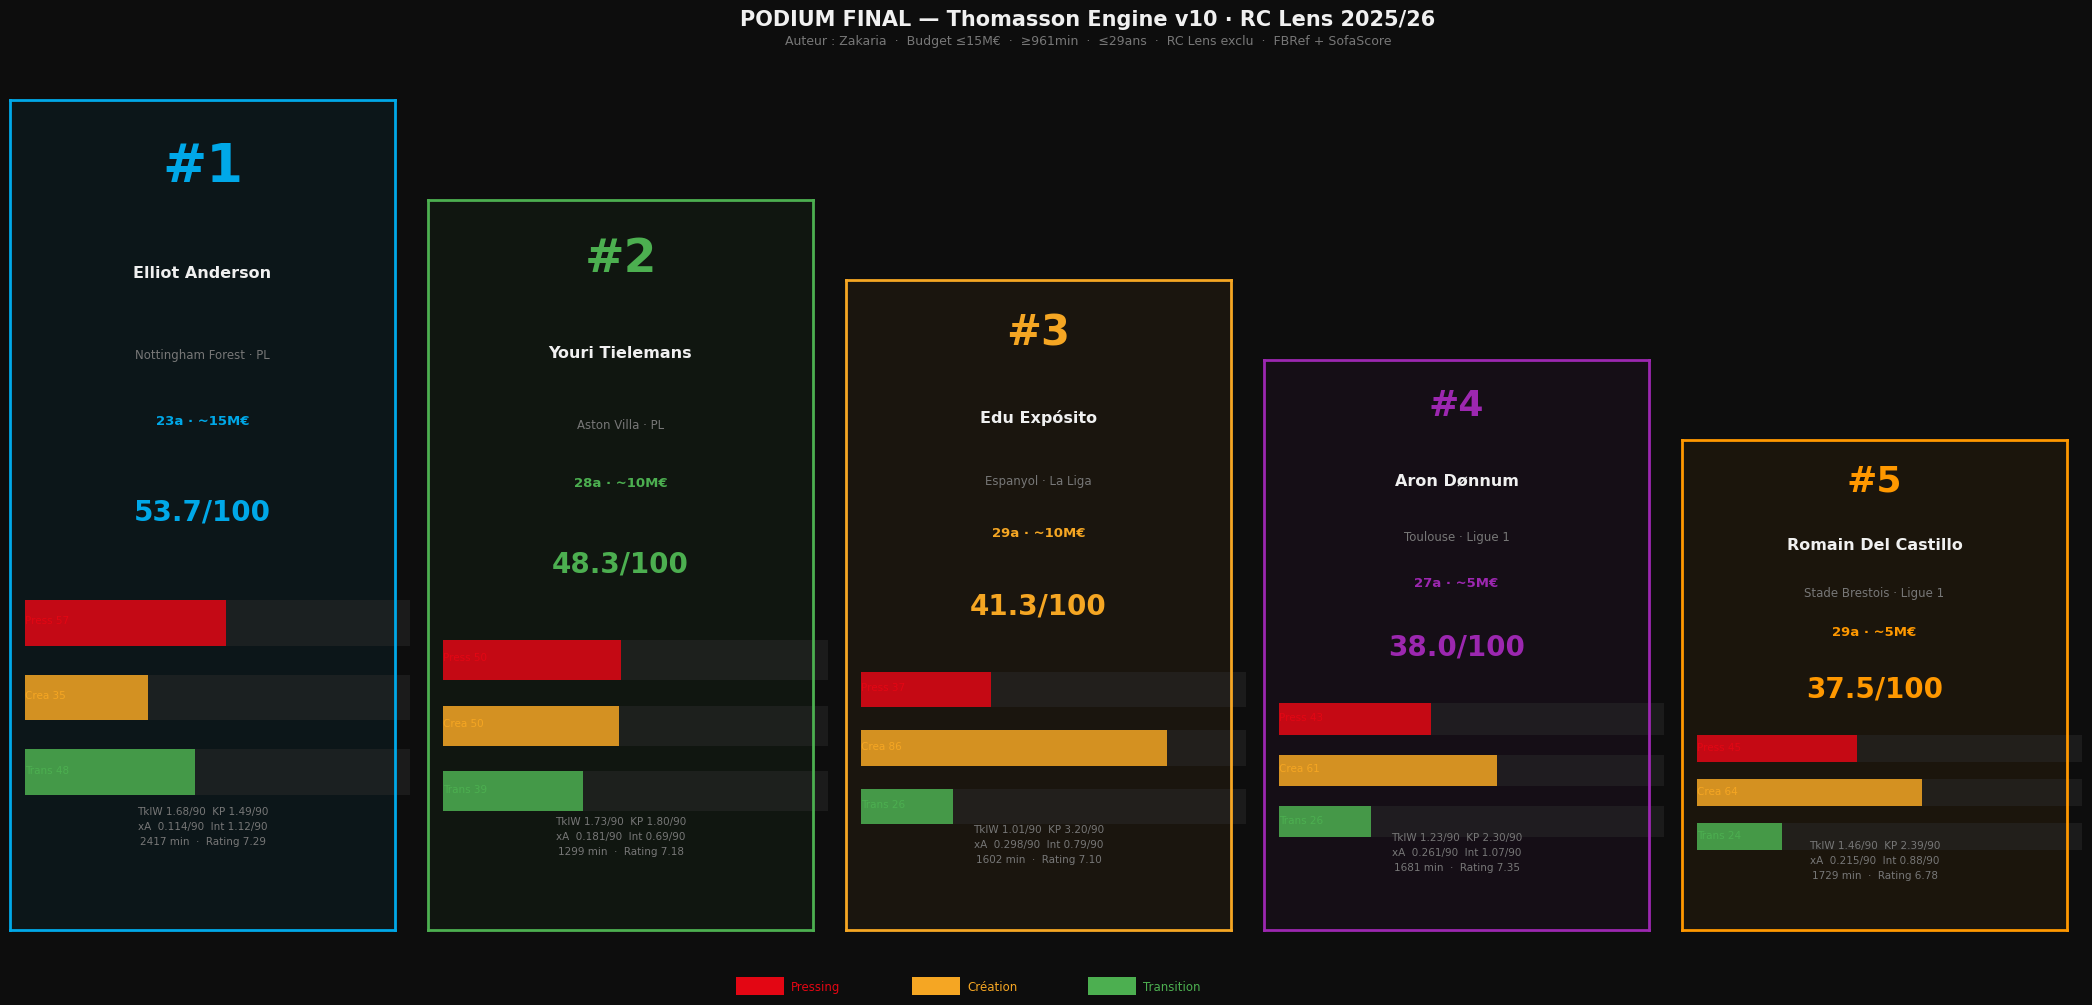

In [30]:
PODIUM5 = [
    ('#1', 'Anderson',  'Elliot Anderson',     'Nottingham Forest · PL',  '23a · ~15M€', B),
    ('#2', 'Tielemans', 'Youri Tielemans',     'Aston Villa · PL',        '28a · ~10M€', VT),
    ('#3', 'Expósito',  'Edu Expósito',        'Espanyol · La Liga',      '29a · ~10M€', OR),
    ('#4', 'Dønnum',    'Aron Dønnum',         'Toulouse · Ligue 1',      '27a · ~5M€',  PU),
    ('#5', 'Castillo',  'Romain Del Castillo', 'Stade Brestois · Ligue 1','29a · ~5M€',  OG),
]

fig = plt.figure(figsize=(22, 10), facecolor=F)
fig.patch.set_facecolor(F)

N_CARDS = 5
C_W = 0.175   # largeur carte
GAP = 0.015   # espace entre cartes
X0S = [0.01 + i*(C_W+GAP) for i in range(N_CARDS)]
# Hauteurs décroissantes — #1 le plus haut
C_HS = [0.90, 0.80, 0.72, 0.64, 0.56]

for idx,((rank,kw,name,club,meta,col),x0,ch) in enumerate(zip(PODIUM5, X0S, C_HS)):
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): continue
    r = r.iloc[0]

    # Axe carte
    ax = fig.add_axes([x0, 0.07, C_W, ch - 0.07])
    ax.set_facecolor(mcolors.to_rgba(col, 0.06))
    for sp in ax.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])

    # ── Contenu carte ──────────────────────────────────────────────────────
    fs_rank = max(26, 38 - idx*4)
    ax.text(0.5, 0.95, rank, ha='center', va='top', transform=ax.transAxes,
            fontsize=fs_rank, color=col, fontweight='bold')
    ax.text(0.5, 0.80, name, ha='center', va='top', transform=ax.transAxes,
            fontsize=11.5, color=W, fontweight='bold')
    ax.text(0.5, 0.70, club, ha='center', va='top', transform=ax.transAxes,
            fontsize=8.5, color=G)
    ax.text(0.5, 0.62, meta, ha='center', va='top', transform=ax.transAxes,
            fontsize=9.5, color=col, fontweight='bold')
    # Score total
    ax.text(0.5, 0.52, f'{r["s_final_n"]:.1f}/100', ha='center', va='top',
            transform=ax.transAxes, fontsize=20, color=col, fontweight='bold')

    # ── Barres Press / Crea / Trans ────────────────────────────────────────
    BAR_SCORES = [
        ('Press', r['s_press_n'], R),
        ('Crea',  r['s_crea_n'], OR),
        ('Trans', r['s_trans_n'], VT),
    ]
    for i_b,(lbl,val,bc) in enumerate(BAR_SCORES):
        y_b = 0.37 - i_b*0.09
        # Fond gris de la barre
        ax.barh(y_b, 1.0, height=0.055, left=0.04, color=G2, alpha=0.5,
                transform=ax.transAxes, clip_on=False)
        # Barre colorée
        ax.barh(y_b, val/100*0.92, height=0.055, left=0.04, color=bc, alpha=0.85,
                transform=ax.transAxes, clip_on=False)
        ax.text(0.04, y_b+0.002, f'{lbl} {val:.0f}',
                transform=ax.transAxes, fontsize=7.5, color=bc, va='center')

    # ── Stats clés ─────────────────────────────────────────────────────────
    stats = (f"TklW {r.get('TklW_p90',0):.2f}/90  KP {r.get('keyPasses_p90',0):.2f}/90\n"
             f"xA  {r.get('expectedAssists_p90',0):.3f}/90  Int {r.get('interceptions_p90',0):.2f}/90\n"
             f"{r['minutesPlayed']:.0f} min  ·  Rating {r.get('rating',0):.2f}")
    ax.text(0.5, 0.10, stats, ha='center', va='bottom', transform=ax.transAxes,
            fontsize=7.5, color=G, linespacing=1.6)

# ── Titres globaux ─────────────────────────────────────────────────────────
fig.text(0.5, 0.99,
         'PODIUM FINAL — Thomasson Engine v10 · RC Lens 2025/26',
         ha='center', va='top', fontsize=15, color=W, fontweight='bold')
fig.text(0.5, 0.965,
         f'Auteur : Zakaria  ·  Budget ≤{BUDGET_MAX:.0f}M€  ·  ≥{MIN_THRESH:.0f}min  ·  '
         f'≤{AGE_MAX}ans  ·  RC Lens exclu  ·  FBRef + SofaScore',
         ha='center', va='top', fontsize=9, color=G)

# ── Barre légende dimensions en bas ───────────────────────────────────────
for xi,(_,lbl,bc) in enumerate([('', 'Pressing', R), ('', 'Création', OR), ('', 'Transition', VT)]):
    fig.add_artist(mpatches.Rectangle(
        (0.34 + xi*0.08, 0.005), 0.022, 0.018,
        facecolor=bc, transform=fig.transFigure, clip_on=False))
    fig.text(0.365 + xi*0.08, 0.013, lbl, va='center', fontsize=8.5, color=bc)

plt.savefig(f'{FIGDIR}/fig7_podium.png', dpi=150, bbox_inches='tight', facecolor=F)
plt.show();

## 8. Conclusion

In [ ]:
print("=" * 75)
print("THOMASSON ENGINE v10 — VERDICT FINAL")
print(f"Auteur : Zakaria  |  {len(MF)} MF analysés  |  Shortlist : 5 joueurs")
print("=" * 75)
print()
print("CONTRAINTES RESPECTÉES :")
print(f"  Budget    ≤ {BUDGET_MAX:.0f} M€  (Transfermarkt mars 2026 — valeurs confirmées)")
print(f"  Âge       ≤ {AGE_MAX} ans")
print(f"  Minutes   ≥ {MIN_THRESH:.0f} min  (50% du temps de jeu de Thomasson : {T['minutesPlayed']:.0f}min)")
print(f"  Poste     MF confirmé (FBRef + SofaScore · ni DF ni ailier pur)")
print(f"  RC Lens   exclus ({len(joueurs_lens)} joueurs de l'effectif actuel)")
print()

VERDICT = [
    ('#1','Elliot Anderson',    'Nott.Forest·PL', '23a','15M€',
     'Box-to-box PL · pressing + cassage de lignes · très haut volume'),
    ('#2','Youri Tielemans',    'Aston Villa·PL', '28a','10M€',
     'Équilibre Press/Crea · expérience PL · profil le + proche de Thomasson'),
    ('#3','Edu Expósito',       'Espanyol·LaLiga','29a','10M€',
     'Création élite (KP 3.20/90) · biais balle possession à valider'),
    ('#4','Aron Dønnum',        'Toulouse·L1',    '27a','5M€',
     'Best Value For Money · profil création + transition · budgt stretch'),
    ('#5','Romain Del Castillo','Brestois·L1',    '29a','5M€',
     'Expérience L1 · transition solide · option recrutement précoce'),
]

for rank,name,club,age,bud,note in VERDICT:
    kw = name.split()[-1]
    r  = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        print(f"[{rank}] {r['player__name']} · {club} · {age} · {bud}")
        print(f"  Score {r['s_final_n']:.1f}/100  "
              f"Press:{r['s_press_n']:.0f}  Crea:{r['s_crea_n']:.0f}  Trans:{r['s_trans_n']:.0f}")
        print(f"  {r['minutesPlayed']:.0f}min · TklW {r.get('TklW_p90',0):.2f}/90 · "
              f"KP {r.get('keyPasses_p90',0):.2f}/90 · xA {r.get('expectedAssists_p90',0):.3f}/90")
        print(f"  → {note}")
        print()


THOMASSON ENGINE v10 — VERDICT FINAL
Auteur : Zakaria  |  642 MF analysés  |  Shortlist : 5 joueurs

CONTRAINTES RESPECTÉES :
  Budget    ≤ 15 M€  (Transfermarkt mars 2026 — valeurs confirmées)
  Âge       ≤ 29 ans
  Minutes   ≥ 961 min  (50% du temps de jeu de Thomasson : 1922min)
  Poste     MF confirmé (FBRef + SofaScore · ni DF ni ailier pur)
  RC Lens   exclus (24 joueurs de l'effectif actuel)

[#1] Elliot Anderson · Nott.Forest·PL · 23a · 15M€
  Score 53.7/100  Press:57  Crea:35  Trans:48
  2417min · TklW 1.68/90 · KP 1.49/90 · xA 0.114/90
  → Box-to-box PL · pressing + cassage de lignes · très haut volume

[#2] Youri Tielemans · Aston Villa·PL · 28a · 10M€
  Score 48.3/100  Press:50  Crea:50  Trans:39
  1299min · TklW 1.73/90 · KP 1.80/90 · xA 0.181/90
  → Équilibre Press/Crea · expérience PL · profil le + proche de Thomasson

[#3] Edu Expósito · Espanyol·LaLiga · 29a · 10M€
  Score 41.3/100  Press:37  Crea:86  Trans:26
  1602min · TklW 1.01/90 · KP 3.20/90 · xA 0.298/90
  → Cré